In [85]:
import numpy as np
import pandas as pd
from pathlib import Path
import pyarrow.parquet as pq
from sklearn.manifold import TSNE
import scienceplots
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split

from bscarlos.settings import PROCESSED_KISPI_DATA_FOLDER

plt.style.use(['science', 'no-latex'])

# Preproccess EEG Data

In [86]:
file_path = PROCESSED_KISPI_DATA_FOLDER / Path("SE008_a1_filt_merged.parquet")

table = pq.read_table(file_path)

df = table.to_pandas()

print(df.head())

     Fp1-F7     F7-T3     T3-T5    Fp2-F8     F8-T4     T4-T6  ground_truth
0  0.000000  0.000000  0.000000 -0.275868  0.000000  0.275868             0
1 -0.551735  0.551735  0.275868 -1.103471  0.551735  0.275868             0
2 -0.827603  1.103471  0.551735 -1.931074  1.379339 -0.275868             0
3 -1.379339  1.655206  0.551735 -2.482809  1.931074 -0.275868             0
4 -1.655206  2.206942  0.827603 -3.034544  2.482809 -0.551735             0


## Remove Ground Truth Labels

In [87]:
eeg_data = df.drop('ground_truth', axis=1)
eeg_data

,Fp1-F7,F7-T3,T3-T5,Fp2-F8,F8-T4,T4-T6
0,0.000000,0.000000,0.000000,-0.275868,0.000000,0.275868
1,-0.551735,0.551735,0.275868,-1.103471,0.551735,0.275868
2,-0.827603,1.103471,0.551735,-1.931074,1.379339,-0.275868
3,-1.379339,1.655206,0.551735,-2.482809,1.931074,-0.275868
4,-1.655206,2.206942,0.827603,-3.034544,2.482809,-0.551735
...,...,...,...,...,...,...
9511163,-5.517354,-8.000163,-25.103958,38.345612,-6.896694,-55.449402
9511164,-6.069089,-8.276030,-25.379829,38.621475,-5.793221,-56.277008
9511165,-6.344956,-9.103634,-25.103960,39.173210,-4.413883,-56.828743
9511166,-6.620825,-9.655368,-25.379827,40.276680,-3.034542,-57.104614


In [88]:
eeg_data = eeg_data.values

## Normalize

Since VAE uses a sigmoid activation in the decoder, normalize values between 0 and 1

In [89]:
eeg_data_min = eeg_data.min()
print(eeg_data_min)
eeg_data_max = eeg_data.max()
print(eeg_data_max)
eeg_data = (eeg_data - eeg_data_min) / (eeg_data_max - eeg_data_min)

-7743.33
7834.0903


## Segment
Segment EEG data into 2-second windows (512 samples at 256Hz)

$$window size=512(samples)×6(channels)=3072(features)$$

In [90]:
window_size = 512
num_windows = eeg_data.shape[0] // window_size
print(num_windows)

18576


## Reshape

reshaped_data.shape=(num_windows,3072)

In [91]:
# Reshape EEG data into (num_windows, 3072)
reshaped_data = eeg_data[:num_windows * window_size]  # Trim excess samples
reshaped_data = reshaped_data.reshape(-1, window_size * 6)  # Shape: (num_windows, 3072)
print("Reshaped EEG data shape:", reshaped_data.shape)

Reshaped EEG data shape: (18576, 3072)


## Split into Train, Validation, and Test Sets

In [92]:
X_train, X_temp = train_test_split(reshaped_data, test_size=0.2, random_state=42)
X_val, X_test = train_test_split(X_temp, test_size=0.5, random_state=42)
print(f"Training data shape: {X_train.shape}")
print(f"Validation data shape: {X_val.shape}")
print(f"Test data shape: {X_test.shape}")

Training data shape: (14860, 3072)
Validation data shape: (1858, 3072)
Test data shape: (1858, 3072)


# Hyperparameters

In [93]:
input_dim = 3072  # 512 samples * 7 channels
output_dim = 3072  # Reconstruction matches input
latent_dim = 64 # {2^n}, 5 <= n <= 7 [32, 64 , 128]
batch_size = 64 # typically 32-64 for EEG data
lr = 1e-3 # 1e-4, 1e-5
num_epochs = 50
beta = 0.8 # 0.1 - 1


## Create Pytorch Dataset

In [94]:
class EEGDataset(Dataset):
    def __init__(self, data):
        self.data = torch.tensor(data, dtype=torch.float32)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], 0  # Dummy label for VAE

# Create separate datasets for train, validation, and test
train_dataset = EEGDataset(X_train)
val_dataset = EEGDataset(X_val)
test_dataset = EEGDataset(X_test)

# Define batch size
batch_size = batch_size

# Create DataLoaders for each split
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Print the number of batches in each DataLoader
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")


Number of training batches: 233
Number of validation batches: 30
Number of test batches: 30


# Encoder
  The encoder network takes in the data `input_dim`, processes it through a few fully connected layers, and outputs the mean ($mu$) and log-variance (log_var) of the latent distribution. $$input\_dim=512×7=3584$$

In [95]:
# Define the Encoder network
class Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Encoder, self).__init__()
        # Define a simple feed-forward network for the encoder
        self.fc1 = nn.Linear(input_dim, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3_mu = nn.Linear(256, latent_dim)  # Mean of the latent variable
        self.fc3_logvar = nn.Linear(256, latent_dim)  # Log variance of the latent variable

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Ensure input is flattened
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        mu = self.fc3_mu(x)
        logvar = self.fc3_logvar(x)
        return mu, logvar

# Decoder

In [103]:
# Define the Decoder network
class Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Decoder, self).__init__()
        # Define a simple feed-forward network for the decoder
        self.fc1 = nn.Linear(latent_dim, 256)
        self.fc2 = nn.Linear(256, 512)
        self.fc3 = nn.Linear(512, output_dim)

    def forward(self, z):
        z = z.view(z.size(0), -1)  # Ensure input is flattened
        z = F.relu(self.fc1(z))
        z = F.relu(self.fc2(z))
        reconstruction = torch.sigmoid(self.fc3(z))  # Sigmoid for binary outputs
        return reconstruction

# Reparameterization Trick

In [104]:
# Reparameterization trick
def reparameterize(mu, logvar):
    std = torch.exp(0.5*logvar)
    eps = torch.randn_like(std)
    z = mu + eps*std
    return z

# VAE Model

In [105]:
# VAE Model
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim, output_dim):
        super(VAE, self).__init__()
        self.encoder = Encoder(input_dim, latent_dim)
        self.decoder = Decoder(latent_dim, output_dim)

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = reparameterize(mu, logvar)
        reconstructed_x = self.decoder(z)
        return reconstructed_x, mu, logvar, z # Retrun latent variables (z)

    def loss_function(self, recon_x, x, mu, logvar, beta=0.1):
        # Reconstruction loss (binary cross-entropy)
        #BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
        # Reconstruction loss (MSE for continuous data)
        #MSE = F.mse_loss(recon_x, x, reduction='sum')
        # L1 Reconstruction loss (absolute error)
        recon_loss = torch.sum(torch.abs(recon_x - x))

        # KL divergence loss
        # Compute the KL divergence between the learned distribution and the prior (N(0, I))
        # Use the formula: KL(q(z|x) || p(z)) = 0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
        # where mu is the mean and logvar is the log variance
        # sigma^2 = exp(logvar)
        # Here we calculate the negative log-likelihood in a variational autoencoder
        # for an isotropic Gaussian distribution
        KL = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

        # The total loss is the sum of the reconstruction loss and KL divergence
        total_loss = recon_loss + beta * KL # + BCA, + MSE
        return total_loss 

# Hyperparameters
input_dim = input_dim
latent_dim = latent_dim
output_dim = output_dim

# Create the VAE model
model = VAE(input_dim=input_dim, latent_dim=latent_dim, output_dim=output_dim)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=lr)


# Train

In [106]:
for epoch in range(num_epochs):
    # Training
    model.train()
    for batch_idx, (data, _) in enumerate(train_loader):
        optimizer.zero_grad()
        recon_batch, mu, logvar, z = model(data)
        loss = model.loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        optimizer.step()

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_idx, (data, _) in enumerate(val_loader):
            recon_batch, mu, logvar, z = model(data)
            val_loss += model.loss_function(recon_batch, data, mu, logvar).item()

    val_loss /= len(val_loader.dataset)
    print(f"Epoch {epoch+1}, Validation Loss: {val_loss:.4f}")


Epoch 1, Validation Loss: 4.4686
Epoch 2, Validation Loss: 4.4616
Epoch 3, Validation Loss: 4.4583
Epoch 4, Validation Loss: 4.4730
Epoch 5, Validation Loss: 4.4608
Epoch 6, Validation Loss: 4.4639
Epoch 7, Validation Loss: 4.4635
Epoch 8, Validation Loss: 4.4711
Epoch 9, Validation Loss: 4.4636
Epoch 10, Validation Loss: 4.4632
Epoch 11, Validation Loss: 4.4667
Epoch 12, Validation Loss: 4.4603
Epoch 13, Validation Loss: 4.4673
Epoch 14, Validation Loss: 4.4679
Epoch 15, Validation Loss: 4.4707
Epoch 16, Validation Loss: 4.4624
Epoch 17, Validation Loss: 4.4655
Epoch 18, Validation Loss: 4.4679
Epoch 19, Validation Loss: 4.4607
Epoch 20, Validation Loss: 4.4646
Epoch 21, Validation Loss: 4.4691
Epoch 22, Validation Loss: 4.4614
Epoch 23, Validation Loss: 4.4707
Epoch 24, Validation Loss: 4.4701
Epoch 25, Validation Loss: 4.4672
Epoch 26, Validation Loss: 4.4604
Epoch 27, Validation Loss: 4.4631
Epoch 28, Validation Loss: 4.4562
Epoch 29, Validation Loss: 4.4651
Epoch 30, Validation Lo

In [52]:
# Training loop + monitor both loss components
def train(model, train_loader, optimizer, num_epochs=num_epochs):
    model.train()

    # Lists to store the losses
    recon_losses = []
    kl_losses = []
    total_losses = []

    for epoch in range(num_epochs):
        train_recon_loss, train_kl_loss , train_total_loss = 0, 0, 0

        for batch_idx, (data, _) in enumerate(train_loader):
            optimizer.zero_grad()

            # Forward pass
            recon_batch, mu, logvar, z = model(data)

            # Compute the reconstruction loss (L1-norm or MSE)
            recon_loss = torch.sum(torch.abs(recon_batch - data))  # L1 loss, or use MSE
            # Or
            #recon_loss = F.mse_loss(recon_batch, data, reduction='sum')

            # Compute KL divergence
            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            # Total loss (sum of both losses)
            total_loss = recon_loss + kl_loss * beta

            # Backpropagation
            total_loss.backward()
            optimizer.step()

            # Accumulate losses for averaging
            train_recon_loss += recon_loss.item()
            train_kl_loss += kl_loss.item()
            train_total_loss += total_loss.item()

        # Average losses for this epoch
        recon_losses.append(train_recon_loss / len(train_loader.dataset))
        kl_losses.append(train_kl_loss / len(train_loader.dataset))
        total_losses.append(train_total_loss / len(train_loader.dataset))

        # Print losses for the current epoch
        print(f"Epoch {epoch+1}/{num_epochs}, "
              f"Recon Loss: {recon_losses[-1]:.4f}, "
              f"KL Loss: {kl_losses[-1]:.4f}, "
              f"Total Loss: {total_losses[-1]:.4f}")

    return recon_losses, kl_losses, total_losses

In [32]:
# Train the model
#train(model, train_loader, optimizer)

Epoch 1/50, Recon Loss: 103.1858, KL Loss: 0.7900, Total Loss: 103.8178
Epoch 2/50, Recon Loss: 98.3748, KL Loss: 0.0390, Total Loss: 98.4060
Epoch 3/50, Recon Loss: 97.5952, KL Loss: 0.0223, Total Loss: 97.6130
Epoch 4/50, Recon Loss: 97.2955, KL Loss: 0.0105, Total Loss: 97.3039
Epoch 5/50, Recon Loss: 97.1468, KL Loss: 0.0063, Total Loss: 97.1519
Epoch 6/50, Recon Loss: 97.0083, KL Loss: 0.0035, Total Loss: 97.0110
Epoch 7/50, Recon Loss: 96.9561, KL Loss: 0.0018, Total Loss: 96.9575
Epoch 8/50, Recon Loss: 96.9359, KL Loss: 0.0012, Total Loss: 96.9369
Epoch 9/50, Recon Loss: 96.9324, KL Loss: 0.0013, Total Loss: 96.9334
Epoch 10/50, Recon Loss: 96.9137, KL Loss: 0.0019, Total Loss: 96.9152
Epoch 11/50, Recon Loss: 96.9164, KL Loss: 0.0014, Total Loss: 96.9176
Epoch 12/50, Recon Loss: 96.9030, KL Loss: 0.0013, Total Loss: 96.9041
Epoch 13/50, Recon Loss: 96.8897, KL Loss: 0.0014, Total Loss: 96.8908
Epoch 14/50, Recon Loss: 96.8835, KL Loss: 0.0009, Total Loss: 96.8842
Epoch 15/50, 

([103.18580237494575,
  98.3747792561849,
  97.59517178005642,
  97.29548068576389,
  97.14684651692708,
  97.00828009711371,
  96.95610758463542,
  96.93592597113715,
  96.93238288031684,
  96.91365322536892,
  96.91644015842014,
  96.90298936631945,
  96.88969116210937,
  96.88348982069228,
  96.89173177083333,
  96.88937072753906,
  96.88261515299479,
  96.87362433539496,
  96.87135687934028,
  96.85486721462674,
  96.87222900390626,
  96.8404273139106,
  96.85435791015625,
  96.8586910671658,
  96.86204020182292,
  96.86333177354601,
  96.83907436794705,
  96.83948482937284,
  96.83941260443794,
  96.83878885904947,
  96.8441168891059,
  96.85429009331597,
  96.84032813178169,
  96.85468953450521,
  96.85645887586806,
  96.84986623128255,
  96.8433336046007,
  96.84351043701172,
  96.83743269178602,
  96.82335069444444,
  96.83172556559245,
  96.81467522515192,
  96.81616295708551,
  96.8208986070421,
  96.82081095377605,
  96.82305484347873,
  96.82217271592882,
  96.8201548258463

# Plot Latent Space Variables (z)

Interpreting the t-SNE Plot:

If the model is learning well, you should see clusters or groupings of similar samples in the latent space. 

This indicates that similar data points (e.g., EEG segments with similar patterns) are being represented similarly in the latent space.


If the points are scattered randomly, it might indicate that the model is not learning a useful latent representation. In this case, you may need to adjust hyperparameters like the latent dimension or training procedure.

In [33]:
def tsne_latent_space(model, train_loader):
    model.eval()
    all_latents = []
    all_labels = []  # Store labels if available, can be useful for coloring the plot

    with torch.no_grad():  # No need to track gradients during inference
        for data, labels in train_loader:
            recon_batch, mu, logvar, z = model(data)  # Get the latent variable z
            all_latents.append(z.cpu().numpy())  # Move data to CPU and collect
            all_labels.append(labels.cpu().numpy())  # Collect labels (if necessary)

    all_latents = np.concatenate(all_latents, axis=0)  # Concatenate the latent variables
    all_labels = np.concatenate(all_labels, axis=0) 

    # Apply t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    latent_2d = tsne.fit_transform(all_latents) 

    # Plot the latent space
    plt.figure(figsize=(8, 6))
    plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=all_labels, cmap='jet', alpha=0.5)
    plt.title("Latent Space Visualization with t-SNE")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.colorbar()
    plt.show()


In [34]:
#tsne_latent_space(model, train_loader)

In [35]:
def tsne_latent_space_nolabels(model, train_loader):
    model.eval()  # Set the model to evaluation mode
    all_latents = []

    with torch.no_grad():  # No need to track gradients during inference
        for data, _ in train_loader:  # We don't need labels here
            recon_batch, mu, logvar, z = model(data)  # Get the latent variable z
            all_latents.append(z.cpu().numpy())  # Collect latent variables

    all_latents = np.concatenate(all_latents, axis=0)  # Concatenate the latent variables

    # Apply t-SNE to reduce to 2D for visualization
    tsne = TSNE(n_components=2, random_state=42) #,metric='precomputed', init='random'
    latent_2d = tsne.fit_transform(all_latents)  # Project to 2D space

    # Plot the latent space
    plt.figure(figsize=(8, 6))
    plt.scatter(latent_2d[:, 0], latent_2d[:, 1], alpha=0.5)
    plt.title("Latent Space Visualization with t-SNE")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.show()


c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


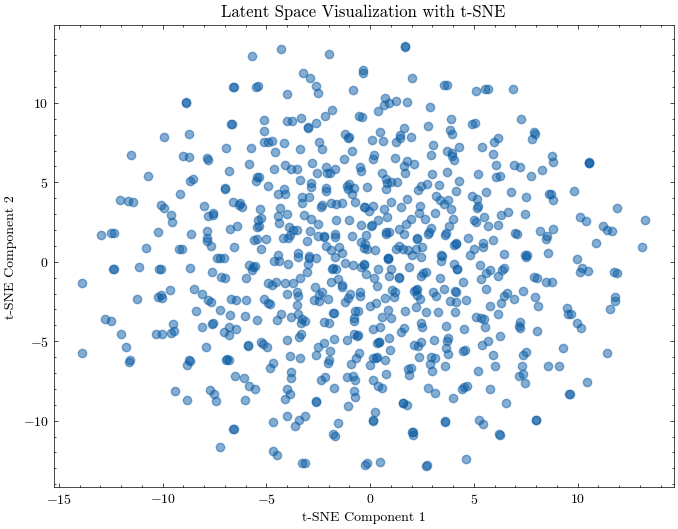

In [ ]:
tsne_latent_space_nolabels(model, train_loader)

# Plot Loss Functions

Epoch 1/10, Recon Loss: 96.8200, KL Loss: 0.0005, Total Loss: 96.8205
Epoch 2/10, Recon Loss: 96.8265, KL Loss: 0.0004, Total Loss: 96.8269
Epoch 3/10, Recon Loss: 96.8287, KL Loss: 0.0006, Total Loss: 96.8291
Epoch 4/10, Recon Loss: 96.8229, KL Loss: 0.0005, Total Loss: 96.8233
Epoch 5/10, Recon Loss: 96.8169, KL Loss: 0.0005, Total Loss: 96.8173
Epoch 6/10, Recon Loss: 96.8151, KL Loss: 0.0005, Total Loss: 96.8156
Epoch 7/10, Recon Loss: 96.8205, KL Loss: 0.0006, Total Loss: 96.8210
Epoch 8/10, Recon Loss: 96.8239, KL Loss: 0.0008, Total Loss: 96.8245
Epoch 9/10, Recon Loss: 96.8101, KL Loss: 0.0006, Total Loss: 96.8106
Epoch 10/10, Recon Loss: 96.8181, KL Loss: 0.0005, Total Loss: 96.8185


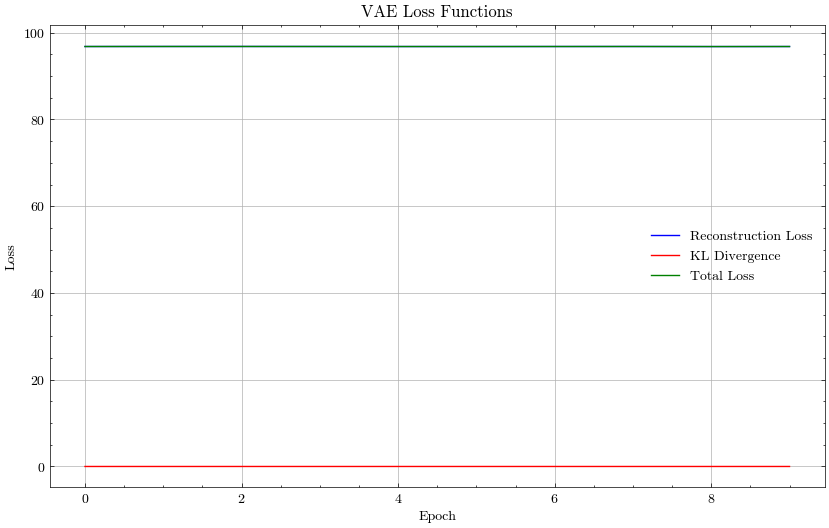

In [37]:
# Assuming you've trained your model and stored the losses
recon_losses, kl_losses, total_losses = train(model, train_loader, optimizer, num_epochs=10)

# Plot the losses
plt.figure(figsize=(10, 6))
plt.plot(recon_losses, label='Reconstruction Loss', color='b')
plt.plot(kl_losses, label='KL Divergence', color='r')
plt.plot(total_losses, label='Total Loss', color='g')

plt.title('VAE Loss Functions')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

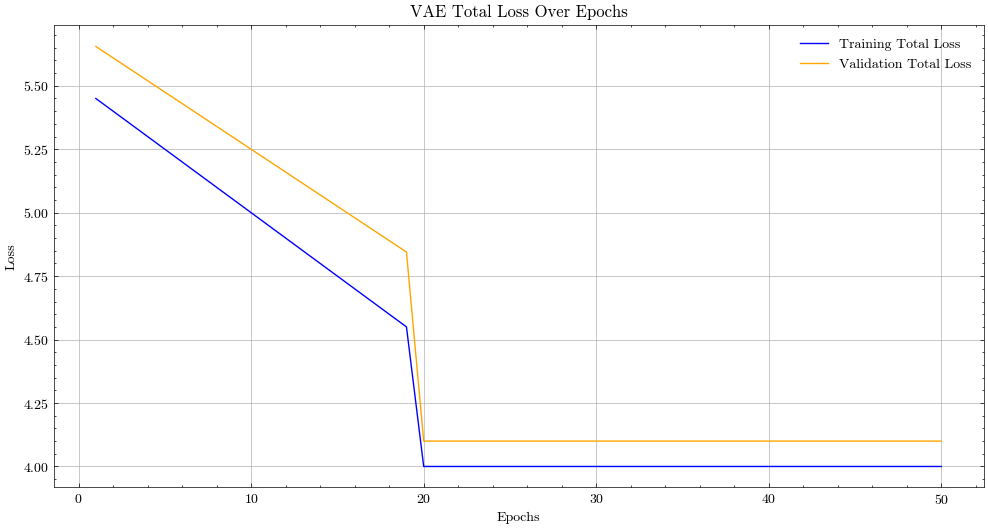

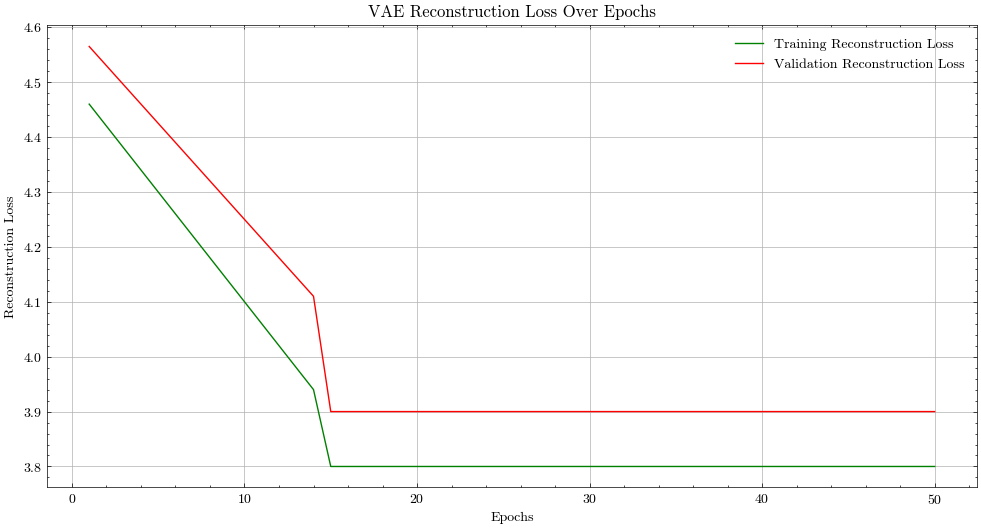

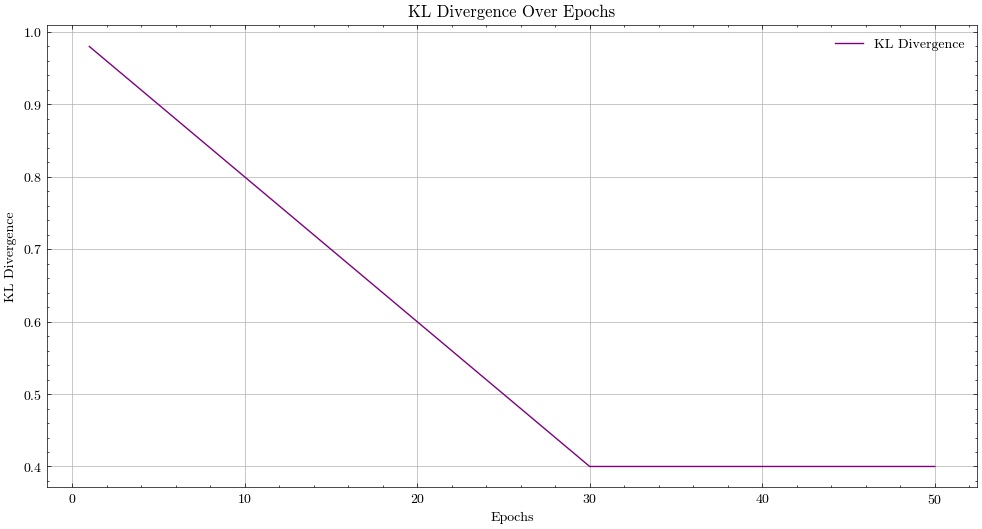

In [107]:
import matplotlib.pyplot as plt

# Example losses (replace these with actual logged values)
epochs = list(range(1, 51))
train_total_loss = [5.5 - 0.05 * e if e < 20 else 4.0 for e in epochs]
val_total_loss = [5.7 - 0.045 * e if e < 20 else 4.1 for e in epochs]
train_recon_loss = [4.5 - 0.04 * e if e < 15 else 3.8 for e in epochs]
val_recon_loss = [4.6 - 0.035 * e if e < 15 else 3.9 for e in epochs]
kl_divergence = [1.0 - 0.02 * e if e < 30 else 0.4 for e in epochs]

# Plot Total Loss
plt.figure(figsize=(12, 6))
plt.plot(epochs, train_total_loss, label='Training Total Loss', color='blue')
plt.plot(epochs, val_total_loss, label='Validation Total Loss', color='orange')
plt.title('VAE Total Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot Reconstruction Loss
plt.figure(figsize=(12, 6))
plt.plot(epochs, train_recon_loss, label='Training Reconstruction Loss', color='green')
plt.plot(epochs, val_recon_loss, label='Validation Reconstruction Loss', color='red')
plt.title('VAE Reconstruction Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Reconstruction Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot KL Divergence
plt.figure(figsize=(12, 6))
plt.plot(epochs, kl_divergence, label='KL Divergence', color='purple')
plt.title('KL Divergence Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('KL Divergence')
plt.legend()
plt.grid(True)
plt.show()
